Device: cuda

=== Top-k 반복 간격 ===
1. tau=183 | R(tau)=0.9648 | weight=0.2008
2. tau= 17 | R(tau)=0.9648 | weight=0.2008
3. tau=167 | R(tau)=0.9590 | weight=0.1996
4. tau= 33 | R(tau)=0.9590 | weight=0.1996
5. tau=150 | R(tau)=0.9565 | weight=0.1991


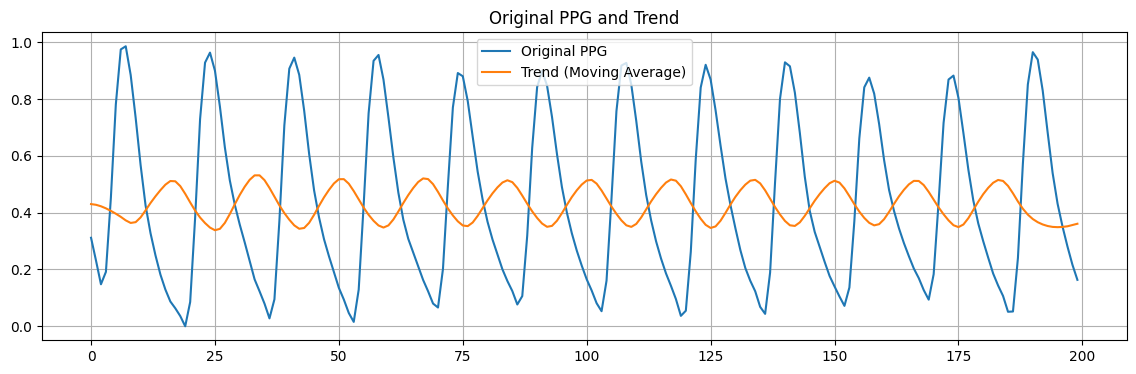

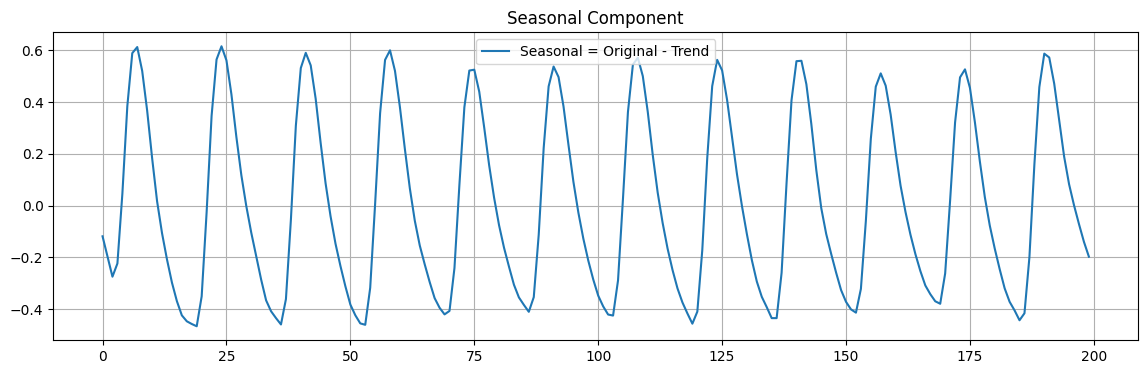

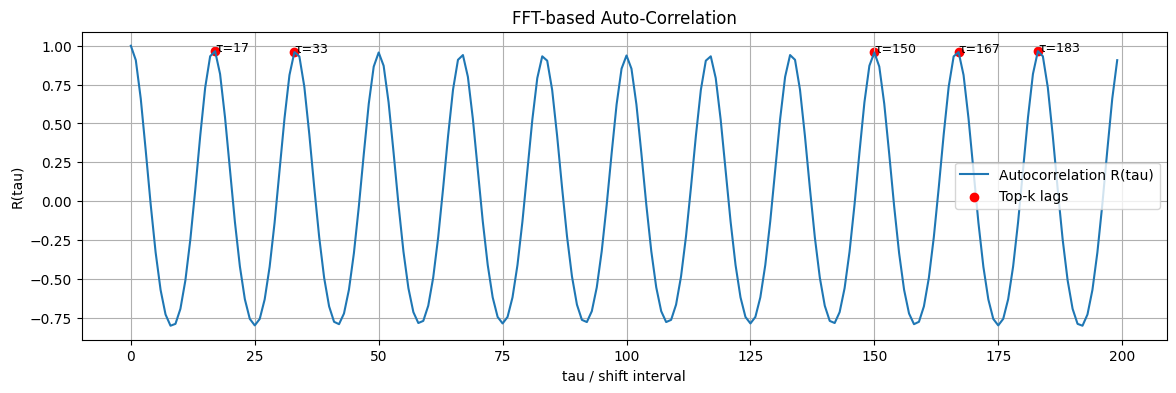

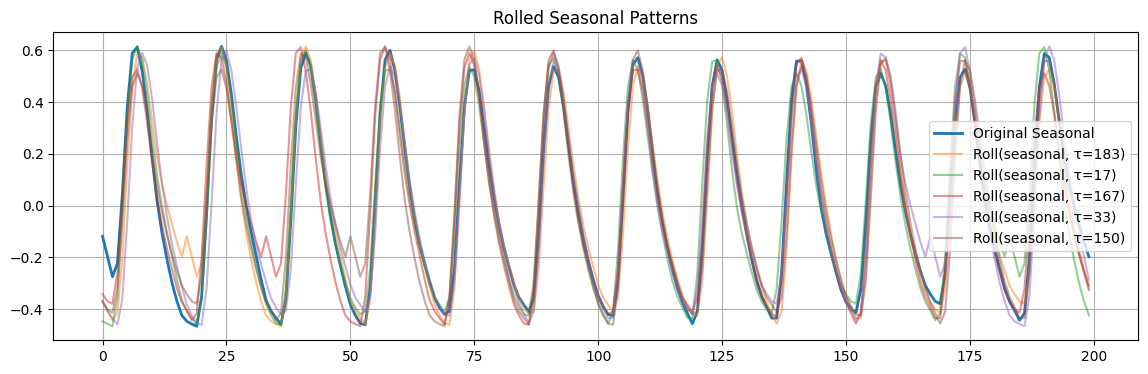

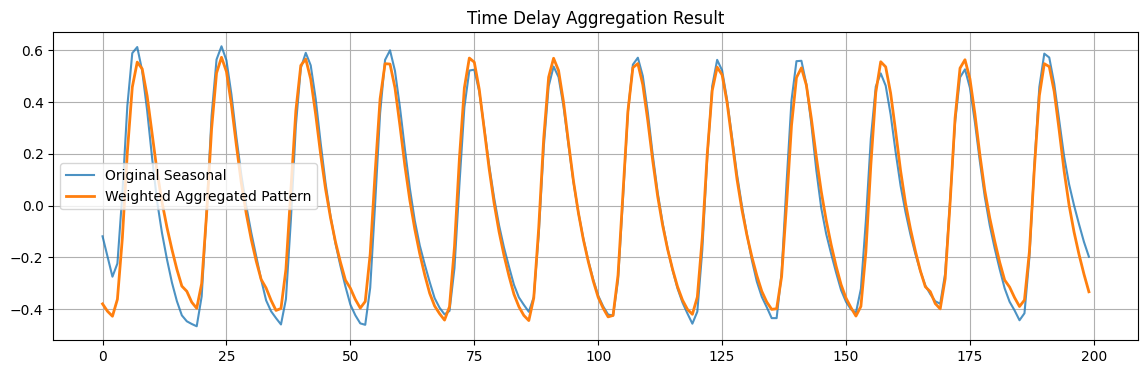

In [1]:
# ============================================================
# PPG로 Autoformer 핵심 흐름 확인하기
# - Decomposition: Trend / Seasonal 분리
# - Auto-Correlation: 어떤 반복 간격이 중요한지 확인
# - Roll + Weighted Sum: 중요한 반복 패턴을 섞어 representation 생성
# ============================================================

import numpy as np
import h5py
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ============================================================
# 0. 설정
# ============================================================

MAT_FILE = "/content/drive/MyDrive/Colab Notebooks/datasets/PulseDB/Normal/p043774.mat"

SEGMENT_INDEX = 0      # PPG segment number
PAD_LEN = 200          # resampling length
MOVING_AVG = 25        # trend 추출용 moving average kernel
TOP_K = 5              # autocorr 상위 몇 개 lag를 볼지

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# ============================================================
# 1. Resampling
# ============================================================

def cubic_resample(ppg, target_len=200):
    """PPG 길이를 target_len으로 맞춤"""
    x_old = np.linspace(0, 1, len(ppg))
    x_new = np.linspace(0, 1, target_len)

    if len(ppg) < 4:
        return np.interp(x_new, x_old, ppg).astype(np.float32)

    try:
        f = interp1d(
            x_old,
            ppg,
            kind="cubic",
            bounds_error=False,
            fill_value="extrapolate"
        )
        return f(x_new).astype(np.float32)
    except Exception:
        return np.interp(x_new, x_old, ppg).astype(np.float32)


# ============================================================
# 2. PPG 한 segment 불러오기
# ============================================================

def load_one_ppg_segment(mat_path, index=0):
    """PulseDB/MIMIC mat 파일에서 PPG_F 한 segment 로드"""
    with h5py.File(mat_path, "r") as f:
        refs = f["Subj_Wins"]["PPG_F"][0]

        if index >= len(refs):
            raise IndexError(f"SEGMENT_INDEX too large. max index = {len(refs)-1}")

        ppg = f[refs[index]][()].squeeze().astype(np.float32)

    return ppg


# ============================================================
# 3. Moving Average Decomposition
# ============================================================

def series_decomp(x, kernel_size=25):
    """
    Autoformer의 SeriesDecomp와 같은 개념

    trend    = moving average
    seasonal = original - trend
    """
    # x: [L]
    x_torch = torch.tensor(x, dtype=torch.float32).view(1, 1, -1)

    pad = (kernel_size - 1) // 2

    # 양끝 값 반복 padding
    front = x_torch[:, :, 0:1].repeat(1, 1, pad)
    end = x_torch[:, :, -1:].repeat(1, 1, pad)
    x_pad = torch.cat([front, x_torch, end], dim=-1)

    # moving average
    trend = F.avg_pool1d(x_pad, kernel_size=kernel_size, stride=1)

    trend = trend.view(-1).numpy()
    seasonal = x - trend

    return seasonal, trend


# ============================================================
# 4. FFT 기반 Auto-Correlation
# ============================================================

def fft_autocorrelation(x):
    """
    Autoformer의 Auto-Correlation 핵심

    모든 lag에 대한 유사도 R(tau)를 FFT로 한 번에 계산
    """
    x = torch.tensor(x, dtype=torch.float32).to(DEVICE)

    # 평균 제거: autocorr peak를 더 보기 쉽게 하기 위함
    x = x - x.mean()

    # [L] -> FFT
    x_fft = torch.fft.rfft(x)

    # FFT(x) * conj(FFT(x))
    power = x_fft * torch.conj(x_fft)

    # inverse FFT -> lag별 autocorrelation
    corr = torch.fft.irfft(power, n=x.shape[0])

    corr = corr.real

    # 보기 쉽게 normalize
    corr = corr / (corr[0].abs() + 1e-8)

    return corr.detach().cpu().numpy()


# ============================================================
# 5. Top-k lag 선택
# ============================================================

def get_topk_lags(corr, top_k=5, ignore_zero=True):
    """
    R(tau)가 큰 lag 선택

    tau:
      얼마나 shift할지

    R(tau):
      그 shift가 얼마나 유사한지
    """
    corr_for_pick = corr.copy()

    if ignore_zero:
        corr_for_pick[0] = -np.inf

    top_idx = np.argsort(corr_for_pick)[-top_k:][::-1]
    top_scores = corr[top_idx]

    weights = torch.softmax(
        torch.tensor(top_scores, dtype=torch.float32),
        dim=0
    ).numpy()

    return top_idx, top_scores, weights


# ============================================================
# 6. Roll + Weighted Aggregation
# ============================================================

def time_delay_aggregation(x, lags, weights):
    """
    선택된 tau만큼 신호를 roll하고,
    R(tau) 기반 weight를 곱해 합침
    """
    rolled_list = []
    agg = np.zeros_like(x, dtype=np.float32)

    for tau, w in zip(lags, weights):
        rolled = np.roll(x, -int(tau))
        rolled_list.append(rolled)
        agg += w * rolled

    return agg, rolled_list


# ============================================================
# 7. 실행
# ============================================================

raw_ppg = load_one_ppg_segment(MAT_FILE, SEGMENT_INDEX)
ppg = cubic_resample(raw_ppg, PAD_LEN)

seasonal, trend = series_decomp(ppg, MOVING_AVG)

# Auto-Correlation은 seasonal에서 보는 게 직관적으로 좋음
corr = fft_autocorrelation(seasonal)

lags, scores, weights = get_topk_lags(corr, TOP_K)

agg, rolled_list = time_delay_aggregation(seasonal, lags, weights)


# ============================================================
# 8. 결과 출력
# ============================================================

print("\n=== Top-k 반복 간격 ===")
for i, (tau, score, w) in enumerate(zip(lags, scores, weights), 1):
    print(f"{i}. tau={tau:3d} | R(tau)={score:.4f} | weight={w:.4f}")


# ============================================================
# 9. 시각화
# ============================================================

plt.figure(figsize=(14, 4))
plt.plot(ppg, label="Original PPG")
plt.plot(trend, label="Trend (Moving Average)")
plt.title("Original PPG and Trend")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(seasonal, label="Seasonal = Original - Trend")
plt.title("Seasonal Component")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(corr, label="Autocorrelation R(tau)")
plt.scatter(lags, scores, color="red", label="Top-k lags")
for tau, score in zip(lags, scores):
    plt.text(tau, score, f"τ={tau}", fontsize=9)
plt.title("FFT-based Auto-Correlation")
plt.xlabel("tau / shift interval")
plt.ylabel("R(tau)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(seasonal, label="Original Seasonal", linewidth=2)
for tau, rolled in zip(lags, rolled_list):
    plt.plot(rolled, alpha=0.5, label=f"Roll(seasonal, τ={tau})")
plt.title("Rolled Seasonal Patterns")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(seasonal, label="Original Seasonal", alpha=0.8)
plt.plot(agg, label="Weighted Aggregated Pattern", linewidth=2)
plt.title("Time Delay Aggregation Result")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
# ============================================================
# PulseDB/MIMIC PPG-only BP Estimation with Autoformer Backbone
# - Input  : PPG_F only
# - Output : SBP, DBP
# - Metric : MAE + SD in mmHg
# ============================================================

import time
import math
import random
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from scipy.interpolate import interp1d
import pandas as pd

# ============================================================
# 0. Config
# ============================================================

MAT_FILE = "/content/drive/MyDrive/Colab Notebooks/datasets/PulseDB/Normal/p043774.mat"

SEGMENT_LIMIT = None
PAD_LEN = 200
SEC_PER_SEGMENT = 10.0

BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Autoformer
D_MODEL = 64
N_HEADS = 4
D_FF = 128
E_LAYERS = 2
D_LAYERS = 1
MOVING_AVG = 25
FACTOR = 3
DROPOUT = 0.1
LABEL_LEN = PAD_LEN // 2
PRED_LEN = PAD_LEN // 2

print("Device:", DEVICE)


# ============================================================
# 1. Utils
# ============================================================

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def cubic_resample(ppg, target_len=PAD_LEN):
    x_old = np.linspace(0, 1, len(ppg))
    x_new = np.linspace(0, 1, target_len)

    if len(ppg) < 4:
        return np.interp(x_new, x_old, ppg).astype(np.float32)

    try:
        f = interp1d(
            x_old,
            ppg,
            kind="cubic",
            bounds_error=False,
            fill_value="extrapolate"
        )
        return f(x_new).astype(np.float32)
    except Exception:
        return np.interp(x_new, x_old, ppg).astype(np.float32)


def segs_from_minutes(minutes):
    return int((minutes * 60.0) / SEC_PER_SEGMENT)


# ============================================================
# 2. Data Loading: PPG_F only
# ============================================================

def load_data_from_mat(mat_path, segment_limit=None):
    segments, targets = [], []

    with h5py.File(mat_path, "r") as f:
        refs = f["Subj_Wins"]["PPG_F"][0]
        sbps = f["Subj_Wins"]["SegSBP"][0]
        dbps = f["Subj_Wins"]["SegDBP"][0]

        total = min(len(refs), segment_limit) if segment_limit else len(refs)

        for i in range(total):
            ppg = f[refs[i]][()].squeeze().astype(np.float32)
            sbp = float(f[sbps[i]][()][0][0])
            dbp = float(f[dbps[i]][()][0][0])

            segments.append(ppg)
            targets.append([sbp, dbp])

            if i % 1000 == 0:
                print(f"Loaded {i}/{total}")

    return segments, np.array(targets, dtype=np.float32)


class PPGOnlyDataset(Dataset):
    def __init__(self, segments, targets_mmHg):
        self.segments = segments
        self.targets = targets_mmHg

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, idx):
        x = cubic_resample(self.segments[idx], PAD_LEN)

        # PPG_F가 이미 0~1이라 추가 normalize 안 함
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(-1)  # [L, 1]

        y = torch.tensor(self.targets[idx], dtype=torch.float32)  # [2]
        return x, y


# ============================================================
# 3. Train-only Label Scaler
# ============================================================

class LabelScaler2D:
    def __init__(self, eps=1e-6):
        self.eps = eps
        self.fitted = False

    def fit(self, y_train):
        y = np.asarray(y_train, dtype=np.float32)
        self.y_min = y.min(axis=0)
        self.y_max = y.max(axis=0)
        self.fitted = True
        return self

    def transform(self, y):
        y_min = torch.tensor(self.y_min, device=y.device, dtype=y.dtype)
        y_max = torch.tensor(self.y_max, device=y.device, dtype=y.dtype)
        return (y - y_min) / (y_max - y_min + self.eps)

    def inverse(self, y_scaled):
        y_min = torch.tensor(self.y_min, device=y_scaled.device, dtype=y_scaled.dtype)
        y_max = torch.tensor(self.y_max, device=y_scaled.device, dtype=y_scaled.dtype)
        return y_scaled * (y_max - y_min + self.eps) + y_min


# ============================================================
# 4. Autoformer Blocks
# ============================================================

class MovingAvg(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)

    def forward(self, x):
        # x: [B, L, C]
        pad = (self.kernel_size - 1) // 2
        front = x[:, 0:1, :].repeat(1, pad, 1)
        end = x[:, -1:, :].repeat(1, pad, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1)).permute(0, 2, 1)
        return x


class SeriesDecomp(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.moving_avg = MovingAvg(kernel_size)

    def forward(self, x):
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend


class MyLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.layernorm = nn.LayerNorm(channels)

    def forward(self, x):
        x_hat = self.layernorm(x)
        bias = torch.mean(x_hat, dim=1, keepdim=True)
        return x_hat - bias


class AutoCorrelation(nn.Module):
    def __init__(self, factor=3, dropout=0.1, output_attention=False):
        super().__init__()
        self.factor = factor
        self.dropout = nn.Dropout(dropout)
        self.output_attention = output_attention

    def time_delay_agg_training(self, values, corr):
        # values: [B, H, C, L]
        B, H, C, L = values.shape
        top_k = max(1, int(self.factor * math.log(L)))

        # batch/head/channel 평균으로 대표 lag 선택
        mean_corr = torch.mean(torch.mean(corr, dim=1), dim=1)  # [B, L]
        index = torch.topk(torch.mean(mean_corr, dim=0), top_k, dim=-1)[1]

        weights = torch.stack([mean_corr[:, index[i]] for i in range(top_k)], dim=-1)
        weights = torch.softmax(weights, dim=-1)

        out = torch.zeros_like(values).float()

        for i in range(top_k):
            # tau만큼 실제로 뺑뺑이 roll
            pattern = torch.roll(values, -int(index[i]), dims=-1)

            # 그 tau의 중요도만큼 반영
            w = weights[:, i].view(B, 1, 1, 1)
            out = out + pattern * w

        return out

    def time_delay_agg_inference(self, values, corr):
        B, H, C, L = values.shape
        top_k = max(1, int(self.factor * math.log(L)))

        mean_corr = torch.mean(torch.mean(corr, dim=1), dim=1)
        weights, delay = torch.topk(mean_corr, top_k, dim=-1)
        weights = torch.softmax(weights, dim=-1)

        init_index = torch.arange(L, device=values.device).view(1, 1, 1, L)
        init_index = init_index.repeat(B, H, C, 1)

        values2 = values.repeat(1, 1, 1, 2)
        out = torch.zeros_like(values).float()

        for i in range(top_k):
            tmp_delay = init_index + delay[:, i].view(B, 1, 1, 1)
            pattern = torch.gather(values2, dim=-1, index=tmp_delay)
            w = weights[:, i].view(B, 1, 1, 1)
            out = out + pattern * w

        return out

    def forward(self, queries, keys, values, attn_mask=None):
        # queries, keys, values: [B, L, H, E]
        B, L, H, E = queries.shape
        _, S, _, D = values.shape

        if L > S:
            zeros = torch.zeros_like(queries[:, :(L - S), :, :])
            keys = torch.cat([keys, zeros], dim=1)
            values = torch.cat([values, zeros], dim=1)
        else:
            keys = keys[:, :L, :, :]
            values = values[:, :L, :, :]

        # Q,K로 모든 shift 간격의 유사도 R(tau)를 FFT로 계산
        q_fft = torch.fft.rfft(queries.permute(0, 2, 3, 1).contiguous(), dim=-1)
        k_fft = torch.fft.rfft(keys.permute(0, 2, 3, 1).contiguous(), dim=-1)

        res = q_fft * torch.conj(k_fft)
        corr = torch.fft.irfft(res, n=L, dim=-1)  # [B, H, E, L]

        # R(tau)가 큰 tau만큼 V를 roll하고 weight를 곱해 합침
        values = values.permute(0, 2, 3, 1).contiguous()  # [B, H, D, L]

        if self.training:
            out = self.time_delay_agg_training(values, corr)
        else:
            out = self.time_delay_agg_inference(values, corr)

        out = out.permute(0, 3, 1, 2).contiguous()  # [B, L, H, D]

        if self.output_attention:
            return out, corr.permute(0, 3, 1, 2)
        return out, None


class AutoCorrelationLayer(nn.Module):
    def __init__(self, d_model, n_heads, factor=3, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        d_keys = d_model // n_heads
        d_values = d_model // n_heads

        self.inner = AutoCorrelation(factor=factor, dropout=dropout)

        self.q_proj = nn.Linear(d_model, d_keys * n_heads)
        self.k_proj = nn.Linear(d_model, d_keys * n_heads)
        self.v_proj = nn.Linear(d_model, d_values * n_heads)
        self.out_proj = nn.Linear(d_values * n_heads, d_model)

    def forward(self, q, k, v, attn_mask=None):
        B, L, _ = q.shape
        _, S, _ = k.shape
        H = self.n_heads

        q = self.q_proj(q).view(B, L, H, -1)
        k = self.k_proj(k).view(B, S, H, -1)
        v = self.v_proj(v).view(B, S, H, -1)

        out, attn = self.inner(q, k, v, attn_mask)
        out = out.view(B, L, -1)

        return self.out_proj(out), attn


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, moving_avg, factor, dropout):
        super().__init__()
        self.attn = AutoCorrelationLayer(d_model, n_heads, factor, dropout)
        self.decomp1 = SeriesDecomp(moving_avg)
        self.decomp2 = SeriesDecomp(moving_avg)

        self.conv1 = nn.Conv1d(d_model, d_ff, kernel_size=1, bias=False)
        self.conv2 = nn.Conv1d(d_ff, d_model, kernel_size=1, bias=False)

        self.dropout = nn.Dropout(dropout)
        self.act = F.gelu

    def forward(self, x):
        # AutoCorr + Residual
        new_x, _ = self.attn(x, x, x)
        x = x + self.dropout(new_x)

        # Trend 제거, Seasonal만 유지
        x, _ = self.decomp1(x)

        # FFN
        y = x
        y = self.dropout(self.act(self.conv1(y.transpose(1, 2))))
        y = self.dropout(self.conv2(y).transpose(1, 2))

        # 다시 Trend 제거
        x, _ = self.decomp2(x + y)
        return x


class Encoder(nn.Module):
    def __init__(self, layers, d_model):
        super().__init__()
        self.layers = nn.ModuleList(layers)
        self.norm = MyLayerNorm(d_model)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.norm(x)


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, c_out, moving_avg, factor, dropout):
        super().__init__()
        self.self_attn = AutoCorrelationLayer(d_model, n_heads, factor, dropout)
        self.cross_attn = AutoCorrelationLayer(d_model, n_heads, factor, dropout)

        self.decomp1 = SeriesDecomp(moving_avg)
        self.decomp2 = SeriesDecomp(moving_avg)
        self.decomp3 = SeriesDecomp(moving_avg)

        self.conv1 = nn.Conv1d(d_model, d_ff, kernel_size=1, bias=False)
        self.conv2 = nn.Conv1d(d_ff, d_model, kernel_size=1, bias=False)

        self.trend_proj = nn.Conv1d(
            d_model,
            c_out,
            kernel_size=3,
            padding=1,
            padding_mode="circular",
            bias=False
        )

        self.dropout = nn.Dropout(dropout)
        self.act = F.gelu

    def forward(self, x, cross):
        # decoder 내부 Seasonal 정제
        x = x + self.dropout(self.self_attn(x, x, x)[0])
        x, trend1 = self.decomp1(x)

        # encoder에서 온 과거 seasonal 정보 활용
        x = x + self.dropout(self.cross_attn(x, cross, cross)[0])
        x, trend2 = self.decomp2(x)

        # FFN
        y = x
        y = self.dropout(self.act(self.conv1(y.transpose(1, 2))))
        y = self.dropout(self.conv2(y).transpose(1, 2))

        x, trend3 = self.decomp3(x + y)

        # Decoder에서 나온 trend는 계속 누적할 것
        trend = trend1 + trend2 + trend3
        trend = self.trend_proj(trend.permute(0, 2, 1)).transpose(1, 2)

        return x, trend


class Decoder(nn.Module):
    def __init__(self, layers, d_model, c_out):
        super().__init__()
        self.layers = nn.ModuleList(layers)
        self.norm = MyLayerNorm(d_model)
        self.proj = nn.Linear(d_model, c_out)

    def forward(self, x, cross, trend):
        for layer in self.layers:
            x, residual_trend = layer(x, cross)
            trend = trend + residual_trend

        x = self.norm(x)
        seasonal = self.proj(x)
        return seasonal, trend


# ============================================================
# 5. PPG-only Autoformer Regressor
# ============================================================

class PPGAutoformerRegressor(nn.Module):
    def __init__(
        self,
        seq_len=200,
        label_len=100,
        pred_len=100,
        enc_in=1,
        c_out=1,
        d_model=64,
        n_heads=4,
        d_ff=128,
        e_layers=2,
        d_layers=1,
        moving_avg=25,
        factor=3,
        dropout=0.1
    ):
        super().__init__()

        self.seq_len = seq_len
        self.label_len = label_len
        self.pred_len = pred_len

        self.decomp = SeriesDecomp(moving_avg)

        # PPG value -> hidden feature
        self.enc_embed = nn.Sequential(
            nn.Linear(enc_in, d_model),
            nn.Dropout(dropout)
        )

        self.dec_embed = nn.Sequential(
            nn.Linear(c_out, d_model),
            nn.Dropout(dropout)
        )

        self.encoder = Encoder(
            [
                EncoderLayer(
                    d_model=d_model,
                    n_heads=n_heads,
                    d_ff=d_ff,
                    moving_avg=moving_avg,
                    factor=factor,
                    dropout=dropout
                )
                for _ in range(e_layers)
            ],
            d_model=d_model
        )

        self.decoder = Decoder(
            [
                DecoderLayer(
                    d_model=d_model,
                    n_heads=n_heads,
                    d_ff=d_ff,
                    c_out=c_out,
                    moving_avg=moving_avg,
                    factor=factor,
                    dropout=dropout
                )
                for _ in range(d_layers)
            ],
            d_model=d_model,
            c_out=c_out
        )

        # Autoformer가 만든 미래 PPG-like representation을 BP로 회귀
        self.regressor = nn.Sequential(
            nn.Linear(pred_len * c_out + d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        # x: [B, L, 1]

        # Decoder 초기화용 trend / seasonal 분리
        seasonal_init, trend_init = self.decomp(x)

        mean = torch.mean(x, dim=1, keepdim=True).repeat(1, self.pred_len, 1)
        zeros = torch.zeros(x.size(0), self.pred_len, x.size(2), device=x.device)

        trend_init = torch.cat(
            [trend_init[:, -self.label_len:, :], mean],
            dim=1
        )

        seasonal_init = torch.cat(
            [seasonal_init[:, -self.label_len:, :], zeros],
            dim=1
        )

        # Encoder
        enc_out = self.enc_embed(x)
        enc_out = self.encoder(enc_out)

        # Decoder
        dec_out = self.dec_embed(seasonal_init)
        seasonal_part, trend_part = self.decoder(dec_out, enc_out, trend_init)

        # Autoformer output sequence
        out_seq = seasonal_part + trend_part          # [B, label_len+pred_len, 1]
        future_seq = out_seq[:, -self.pred_len:, :]   # [B, pred_len, 1]

        # BP regression
        seq_feat = future_seq.reshape(x.size(0), -1)
        enc_feat = enc_out.mean(dim=1)

        pred = self.regressor(torch.cat([seq_feat, enc_feat], dim=1))
        return pred


# ============================================================
# 6. Train / Eval
# ============================================================

def train_one_model(train_loader, val_loader, scaler):
    model = PPGAutoformerRegressor(
        seq_len=PAD_LEN,
        label_len=LABEL_LEN,
        pred_len=PRED_LEN,
        enc_in=1,
        c_out=1,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        d_ff=D_FF,
        e_layers=E_LAYERS,
        d_layers=D_LAYERS,
        moving_avg=MOVING_AVG,
        factor=FACTOR,
        dropout=DROPOUT
    ).to(DEVICE)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.MSELoss()

    best_val = float("inf")
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_losses = []

        for x, y_mmHg in train_loader:
            x = x.to(DEVICE)
            y_mmHg = y_mmHg.to(DEVICE)

            y = scaler.transform(y_mmHg)
            pred = model(x)

            loss = criterion(pred, y)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            train_losses.append(float(loss.item()))

        model.eval()
        val_losses = []

        with torch.no_grad():
            for x, y_mmHg in val_loader:
                x = x.to(DEVICE)
                y_mmHg = y_mmHg.to(DEVICE)

                y = scaler.transform(y_mmHg)
                pred = model(x)

                val_losses.append(float(criterion(pred, y).item()))

        avg_train = float(np.mean(train_losses))
        avg_val = float(np.mean(val_losses)) if len(val_losses) else float("inf")

        if avg_val < best_val:
            best_val = avg_val
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Train {avg_train:.5f} | Val {avg_val:.5f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


def eval_mae_sd_mmHg(model, loader, scaler):
    model.eval()
    errs = []

    with torch.no_grad():
        for x, y_mmHg in loader:
            x = x.to(DEVICE)
            y_mmHg = y_mmHg.to(DEVICE)

            pred_scaled = model(x)
            pred_mmHg = scaler.inverse(pred_scaled)

            err = (pred_mmHg - y_mmHg).detach().cpu().numpy()
            errs.append(err)

    if len(errs) == 0:
        return dict(mae_sbp=np.nan, sd_sbp=np.nan, mae_dbp=np.nan, sd_dbp=np.nan, n=0)

    E = np.concatenate(errs, axis=0)
    e_sbp = E[:, 0]
    e_dbp = E[:, 1]

    return dict(
        mae_sbp=float(np.mean(np.abs(e_sbp))),
        sd_sbp=float(np.std(e_sbp, ddof=0)),
        mae_dbp=float(np.mean(np.abs(e_dbp))),
        sd_dbp=float(np.std(e_dbp, ddof=0)),
        n=int(E.shape[0])
    )


# ============================================================
# 7. Experiment: time-aware multi-start sweep
# ============================================================

def run_autoformer_ppg_only():
    set_seed(SEED)

    segments, targets_mmHg = load_data_from_mat(MAT_FILE, SEGMENT_LIMIT)
    ds = PPGOnlyDataset(segments, targets_mmHg)

    total_len = len(ds)
    print(f"\n[Data Ready] total_len={total_len}")

    TRAIN_DUR_MIN = 10
    TEST_DURATION_MIN = 5

    sweep_time_gap = [0, 5, 10, 15]
    test_end_offsets_min = [0, 5, 10, 15, 20]

    tr_dur_segs = segs_from_minutes(TRAIN_DUR_MIN)
    test_dur_segs = segs_from_minutes(TEST_DURATION_MIN)
    test_end_offsets_segs = [segs_from_minutes(m) for m in test_end_offsets_min]

    rows = []
    total_iter = len(sweep_time_gap) * len(test_end_offsets_min)
    it = 0
    t0 = time.time()

    for off_min, off_segs in zip(test_end_offsets_min, test_end_offsets_segs):
        test_end = total_len - off_segs
        test_start = test_end - test_dur_segs

        if test_start <= 0:
            continue

        test_indices = list(range(test_start, test_end))

        for gap_min in sweep_time_gap:
            it += 1
            print(f"\n[{it}/{total_iter}] Offset={off_min}m | Gap={gap_min}m")

            gap_segs = segs_from_minutes(gap_min)

            train_end = test_start - gap_segs
            train_start = train_end - tr_dur_segs

            if train_start < 0 or train_start >= train_end:
                rows.append({
                    "TestEndOffset_min": off_min,
                    "TrainDur_min": TRAIN_DUR_MIN,
                    "TimeGap_min": gap_min,
                    "MAE_SBP": np.nan,
                    "SD_SBP": np.nan,
                    "MAE_DBP": np.nan,
                    "SD_DBP": np.nan,
                    "train_n": 0,
                    "val_n": 0,
                    "test_n": len(test_indices),
                    "OK": 0
                })
                continue

            train_indices = list(range(train_start, train_end))

            # train 내부 마지막 20%를 validation
            n_total = len(train_indices)
            n_val = max(1, int(n_total * 0.20))

            real_train_idx = train_indices[:-n_val]
            val_idx = train_indices[-n_val:]

            y_train = targets_mmHg[np.array(real_train_idx)]
            scaler = LabelScaler2D().fit(y_train)

            train_loader = DataLoader(
                Subset(ds, real_train_idx),
                batch_size=BATCH_SIZE,
                shuffle=True
            )

            val_loader = DataLoader(
                Subset(ds, val_idx),
                batch_size=BATCH_SIZE,
                shuffle=False
            )

            test_loader = DataLoader(
                Subset(ds, test_indices),
                batch_size=BATCH_SIZE,
                shuffle=False
            )

            model = train_one_model(train_loader, val_loader, scaler)
            stat = eval_mae_sd_mmHg(model, test_loader, scaler)

            print(
                f"Test MAE | SBP={stat['mae_sbp']:.3f}, "
                f"DBP={stat['mae_dbp']:.3f}"
            )

            rows.append({
                "TestEndOffset_min": off_min,
                "TrainDur_min": TRAIN_DUR_MIN,
                "TimeGap_min": gap_min,
                "MAE_SBP": stat["mae_sbp"],
                "SD_SBP": stat["sd_sbp"],
                "MAE_DBP": stat["mae_dbp"],
                "SD_DBP": stat["sd_dbp"],
                "train_n": len(real_train_idx),
                "val_n": len(val_idx),
                "test_n": len(test_indices),
                "OK": 1
            })

    df = pd.DataFrame(rows)
    df_ok = df[df["OK"] == 1].copy()

    summary = []

    for gap_min, g in df_ok.groupby("TimeGap_min"):
        sbp = g["MAE_SBP"].values
        dbp = g["MAE_DBP"].values
        bottleneck = np.maximum(sbp, dbp)
        pass_mask = (sbp <= 5.0) & (dbp <= 5.0)

        summary.append({
            "TrainDur_min": TRAIN_DUR_MIN,
            "TimeGap_min": int(gap_min),
            "NumOffsets": int(len(g)),
            "SBP_mean": float(np.mean(sbp)),
            "SBP_std": float(np.std(sbp, ddof=0)),
            "SBP_worst": float(np.max(sbp)),
            "DBP_mean": float(np.mean(dbp)),
            "DBP_std": float(np.std(dbp, ddof=0)),
            "DBP_worst": float(np.max(dbp)),
            "Bottleneck_mean": float(np.mean(bottleneck)),
            "Bottleneck_worst": float(np.max(bottleneck)),
            "PASS_rate": float(np.mean(pass_mask))
        })

    df_sum = pd.DataFrame(summary).sort_values("TimeGap_min")

    print("\n=== PPG-only Autoformer Summary ===")
    print(df_sum)

    raw_path = "ppg_only_autoformer_raw.csv"
    sum_path = "ppg_only_autoformer_summary.csv"

    df.to_csv(raw_path, index=False)
    df_sum.to_csv(sum_path, index=False)

    print(f"\nSaved: {raw_path}")
    print(f"Saved: {sum_path}")

    print(f"\nElapsed: {(time.time() - t0) / 60:.1f} min")

    return df, df_sum


# ============================================================
# 8. Run
# ============================================================

if __name__ == "__main__":
    df_raw, df_sum = run_autoformer_ppg_only()

Device: cuda
Loaded 0/1943
Loaded 1000/1943

[Data Ready] total_len=1943

[1/20] Offset=0m | Gap=0m
Epoch 001 | Train 0.21221 | Val 0.27377
Epoch 010 | Train 0.07457 | Val 0.11511
Epoch 020 | Train 0.03752 | Val 0.16197
Epoch 030 | Train 0.03427 | Val 0.15979
Epoch 040 | Train 0.02346 | Val 0.17383
Epoch 050 | Train 0.01689 | Val 0.18097
Epoch 060 | Train 0.01197 | Val 0.16311
Epoch 070 | Train 0.01127 | Val 0.17819
Epoch 080 | Train 0.01004 | Val 0.15911
Epoch 090 | Train 0.01199 | Val 0.16256
Epoch 100 | Train 0.00927 | Val 0.17354
Test MAE | SBP=4.742, DBP=1.106

[2/20] Offset=0m | Gap=5m
Epoch 001 | Train 0.09499 | Val 0.78143
Epoch 010 | Train 0.04372 | Val 0.72699
Epoch 020 | Train 0.04268 | Val 0.71005
Epoch 030 | Train 0.03991 | Val 0.68768
Epoch 040 | Train 0.03596 | Val 0.67856
Epoch 050 | Train 0.02987 | Val 0.67553
Epoch 060 | Train 0.02881 | Val 0.74492
Epoch 070 | Train 0.01892 | Val 0.66032
Epoch 080 | Train 0.01114 | Val 0.63811
Epoch 090 | Train 0.01889 | Val 0.63745
E